In [1]:
pip install opencv-python


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install --upgrade pip

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [4]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from zipfile import ZipFile
from urllib.request import urlretrieve

from IPython.display import Image

%matplotlib inline

In [5]:
print("hello")

hello


In [6]:
def download_and_unzip(url, save_path):
    print(f"Downloading and extracting assests....", end="")

    # Downloading zip file using urllib package.
    urlretrieve(url, save_path)

    try:
        # Extracting zip file using the zipfile package.
        with ZipFile(save_path) as z:
            # Extract ZIP file contents in the same directory.
            z.extractall(os.path.split(save_path)[0])

        print("Done")

    except Exception as e:
        print("\nInvalid file.", e)

In [7]:
URL = r"https://www.dropbox.com/s/qhhlqcica1nvtaw/opencv_bootcamp_assets_NB1.zip?dl=1"

asset_zip_path = os.path.join(os.getcwd(), f"opencv_bootcamp_assets_NB1.zip")

# Download if assest ZIP does not exists. 
if not os.path.exists(asset_zip_path):
    download_and_unzip(URL, asset_zip_path) 

In [8]:
cb_image = cv2.imread("checkerboard_18x18.png",0)

In [9]:
print(cb_image)

[[  0   0   0   0   0   0 255 255 255 255 255 255   0   0   0   0   0   0]
 [  0   0   0   0   0   0 255 255 255 255 255 255   0   0   0   0   0   0]
 [  0   0   0   0   0   0 255 255 255 255 255 255   0   0   0   0   0   0]
 [  0   0   0   0   0   0 255 255 255 255 255 255   0   0   0   0   0   0]
 [  0   0   0   0   0   0 255 255 255 255 255 255   0   0   0   0   0   0]
 [  0   0   0   0   0   0 255 255 255 255 255 255   0   0   0   0   0   0]
 [255 255 255 255 255 255   0   0   0   0   0   0 255 255 255 255 255 255]
 [255 255 255 255 255 255   0   0   0   0   0   0 255 255 255 255 255 255]
 [255 255 255 255 255 255   0   0   0   0   0   0 255 255 255 255 255 255]
 [255 255 255 255 255 255   0   0   0   0   0   0 255 255 255 255 255 255]
 [255 255 255 255 255 255   0   0   0   0   0   0 255 255 255 255 255 255]
 [255 255 255 255 255 255   0   0   0   0   0   0 255 255 255 255 255 255]
 [  0   0   0   0   0   0 255 255 255 255 255 255   0   0   0   0   0   0]
 [  0   0   0   0   0   0

In [10]:
# size of the image
print(cb_image.shape)

# data type of image 
print(cb_image.dtype)

(18, 18)
uint8


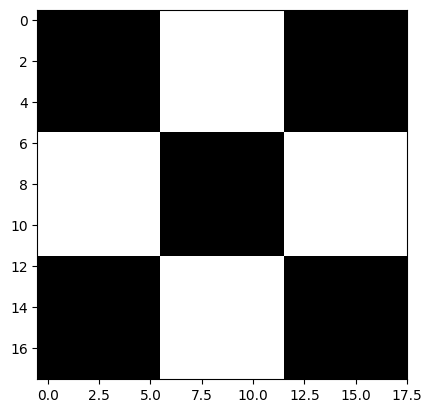

In [11]:
#Display img using matplotlib
plt.imshow(cb_image, cmap = "gray")

In [12]:
coke_image = cv2.imread("coca-cola-logo.png",1)
# image size and datatype
print(coke_image.shape, coke_image.dtype)


(700, 700, 3) uint8


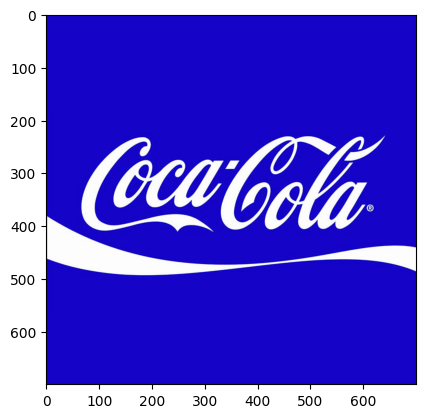

In [13]:
plt.imshow(coke_image)

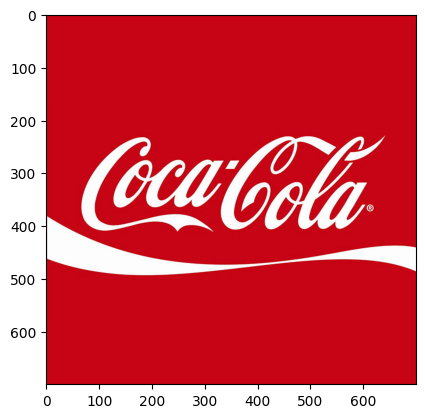

In [14]:
coke_image_channels_reversed = coke_image[:,:,::-1]
plt.imshow(coke_image_channels_reversed)

In [15]:
img_NZ_bgr = cv2.imread("New_Zealand_Lake.jpg",cv2.IMREAD_COLOR)


In [16]:
b,g,r = cv2.split(img_NZ_bgr)

Text(0.5, 1.0, 'Merged Image')

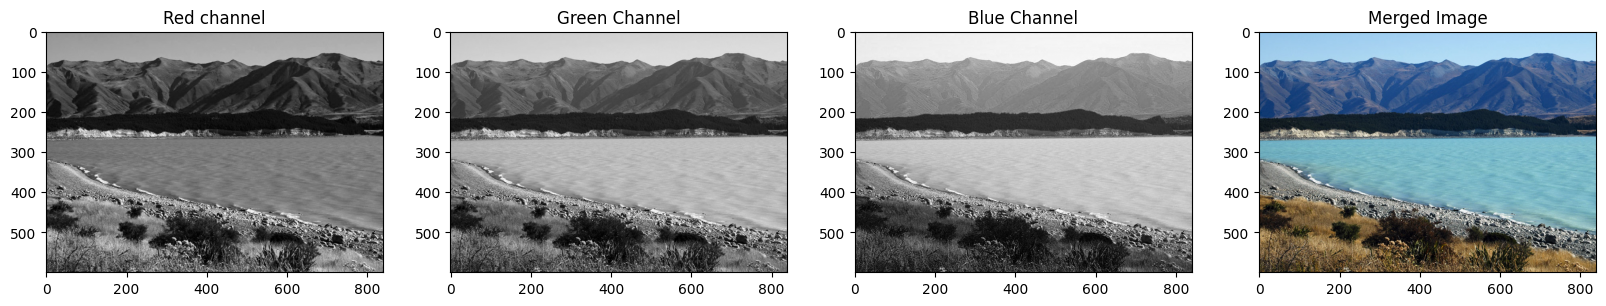

In [17]:
plt.figure(figsize=[20,5])
plt.subplot(141)
plt.imshow(r,cmap = "gray")
plt.title("Red channel")

plt.subplot(142)
plt.imshow(g,cmap = "gray")
plt.title("Green Channel")

plt.subplot(143)
plt.imshow(b, cmap = "gray")
plt.title("Blue Channel")

plt.subplot(144)

im_merged = cv2.merge((b,g,r))
plt.imshow(im_merged[:,:,::-1])
plt.title("Merged Image")

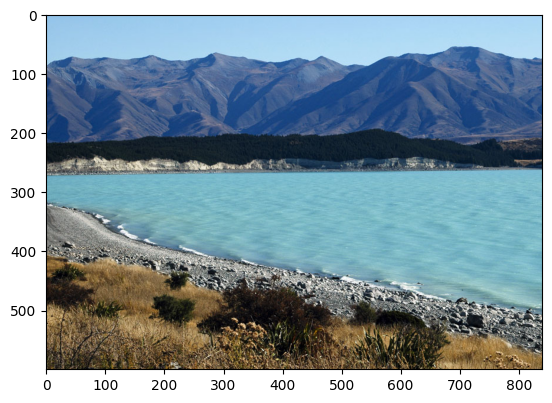

In [18]:
#converting to rgb color space
img_NZ_rgb = cv2.cvtColor(img_NZ_bgr, cv2.COLOR_BGR2RGB)
plt.imshow(img_NZ_rgb)

Text(0.5, 1.0, 'origional')

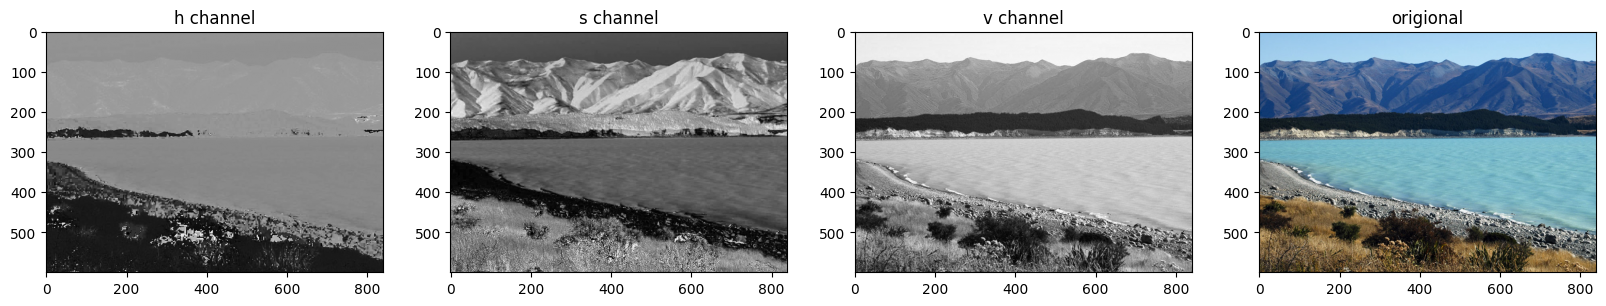

In [19]:
#Changing to HSV color space
img_NZ_hsv = cv2.cvtColor(img_NZ_bgr, cv2.COLOR_BGR2HSV)
h,s,v = cv2.split(img_NZ_hsv)

plt.figure(figsize = [20,5])

plt.subplot(141)
plt.imshow(h, cmap = "gray")
plt.title("h channel")

plt.subplot(142); plt.imshow(s,cmap = "gray"); plt.title("s channel")

plt.subplot(143); plt.imshow(v, cmap = "gray"); plt.title("v channel")

plt.subplot(144); plt.imshow(img_NZ_rgb); plt.title("origional")

Text(0.5, 1.0, 'merged')

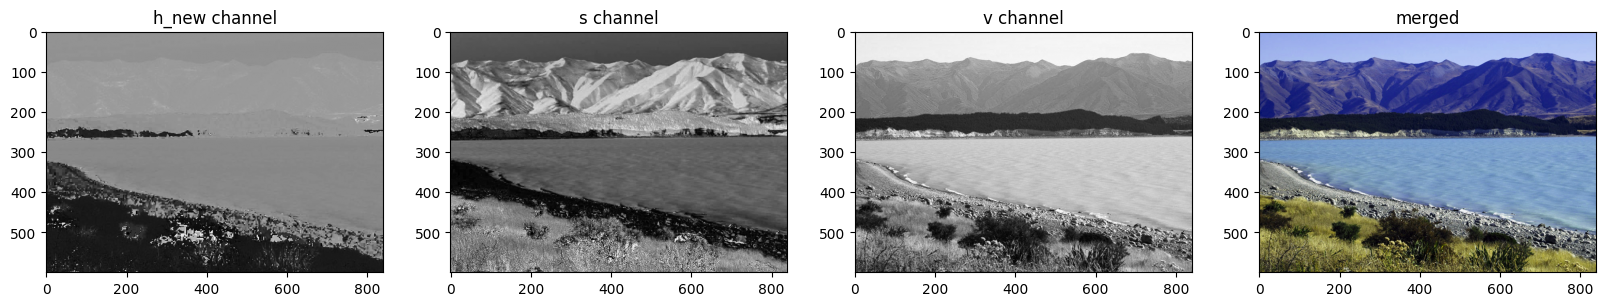

In [20]:
# modyfying a channel in HSV and then printing updated img
h_new = h + 10
img_NZ_hsv_modified = cv2.merge((h_new,s,v))
img_NZ_rgb_modified = cv2.cvtColor(img_NZ_hsv_modified, cv2.COLOR_HSV2RGB)
img_NZ_bgr_modified = cv2.cvtColor(img_NZ_rgb_modified, cv2.COLOR_RGB2BGR)

plt.figure(figsize = [20,5])

plt.subplot(141); plt.imshow(h_new, cmap = "gray"); plt.title("h_new channel")

plt.subplot(142); plt.imshow(s, cmap = "gray"); plt.title("s channel")

plt.subplot(143); plt.imshow(v, cmap = "gray"); plt.title("v channel")

plt.subplot(144); plt.imshow(img_NZ_rgb_modified); plt.title("merged")


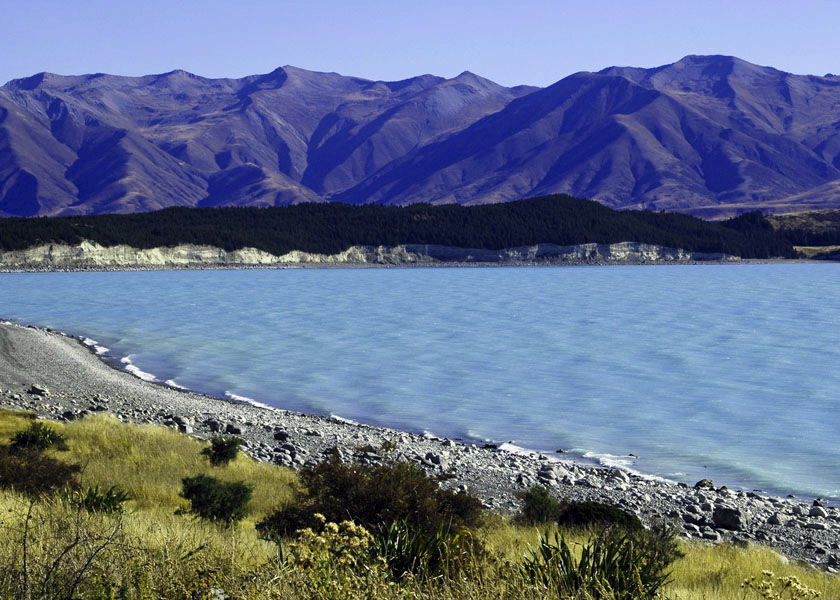

In [21]:
# Saving the images 
cv2.imwrite("img_NZ_rgb_modified.png",img_NZ_bgr_modified)

Image(filename = "img_NZ_rgb_modified.png")

In [22]:
# Reading image as color
img_NZ_bgr =  cv2.imread("img_NZ_rgb_modified.png", cv2.IMREAD_COLOR)
print(img_NZ_bgr.shape)

img_NZ_gray = cv2.imread("img_NZ_rgb_modified.png", cv2.IMREAD_GRAYSCALE)
print(img_NZ_gray.shape)

(600, 840, 3)
(600, 840)


In [23]:
# OpenCV imshow
cv2.namedWindow("w1")
cv2.imshow("w1", img_NZ_bgr)
cv2.waitKey(0)

-1

In [24]:
os.getcwd()

'D:\\MY WORK\\AeroNITK\\opencv-bootcamp'

In [25]:
!git checkout module-01


Already on 'module-01'


In [26]:
!git status


On branch module-01
Untracked files:
  (use "git add <file>..." to include in what will be committed)
	.ipynb_checkpoints/
	New_Zealand_Lake.jpg
	checkerboard_18x18.png
	checkerboard_84x84.jpg
	checkerboard_color.png
	checkerboard_fuzzy_18x18.jpg
	coca-cola-logo.png
	display_image.py
	img_NZ_bgr_modified.png
	img_NZ_rgb_modified.png
	module-01.ipynb
	opencv_bootcamp_assets_NB1.zip

nothing added to commit but untracked files present (use "git add" to track)


In [28]:
!echo ".ipynb_checkpoints/" >> .gitignore
!echo "*.zip" >> .gitignore

In [29]:
!git status 

On branch module-01
Untracked files:
  (use "git add <file>..." to include in what will be committed)
	.gitignore
	.ipynb_checkpoints/
	New_Zealand_Lake.jpg
	checkerboard_18x18.png
	checkerboard_84x84.jpg
	checkerboard_color.png
	checkerboard_fuzzy_18x18.jpg
	coca-cola-logo.png
	display_image.py
	img_NZ_bgr_modified.png
	img_NZ_rgb_modified.png
	module-01.ipynb
	opencv_bootcamp_assets_NB1.zip

nothing added to commit but untracked files present (use "git add" to track)


In [30]:
!git add .

In [31]:
!git status

On branch module-01
Changes to be committed:
  (use "git restore --staged <file>..." to unstage)
	new file:   .gitignore
	new file:   .ipynb_checkpoints/module-01-checkpoint.ipynb
	new file:   New_Zealand_Lake.jpg
	new file:   checkerboard_18x18.png
	new file:   checkerboard_84x84.jpg
	new file:   checkerboard_color.png
	new file:   checkerboard_fuzzy_18x18.jpg
	new file:   coca-cola-logo.png
	new file:   display_image.py
	new file:   img_NZ_bgr_modified.png
	new file:   img_NZ_rgb_modified.png
	new file:   module-01.ipynb
	new file:   opencv_bootcamp_assets_NB1.zip



In [34]:
!git rm --cached .ipynb_checkpoints/module-01-checkpoint.ipynb

rm '.ipynb_checkpoints/module-01-checkpoint.ipynb'


In [35]:
!git status

On branch module-01
Changes to be committed:
  (use "git restore --staged <file>..." to unstage)
	new file:   .gitignore
	new file:   New_Zealand_Lake.jpg
	new file:   checkerboard_18x18.png
	new file:   checkerboard_84x84.jpg
	new file:   checkerboard_color.png
	new file:   checkerboard_fuzzy_18x18.jpg
	new file:   coca-cola-logo.png
	new file:   display_image.py
	new file:   img_NZ_bgr_modified.png
	new file:   img_NZ_rgb_modified.png
	new file:   module-01.ipynb

Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   module-01.ipynb

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	.ipynb_checkpoints/
	opencv_bootcamp_assets_NB1.zip



In [ ]:
git